## Chuẩn bị dữ liệu 

In [3]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

In [4]:
img_org = cv2.imread('/home/tuong/Courses/CV/opencv-learning/sun.png')
# Convert BGR to RGB
img = cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)

In [10]:
def display_images(*images, titles=None, max_cols=5):
    num_images = min(len(images), 12)  # Giới hạn tối đa 10 ảnh
    
    if num_images == 0:
        print("No images to display.")
        return
    
    # Tính toán số hàng và cột
    cols = min(num_images, max_cols)
    rows = (num_images + cols - 1) // cols
    
    # Tạo figure
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    # Ép kiểu axes thành mảng 1 chiều để dễ truy vấn trong vòng lặp
    if num_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    for i in range(num_images):
        img = images[i]
        
        # Kiểm tra nếu là ảnh xám (2D) hoặc ảnh màu (3D)
        if len(img.shape) == 2:
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].imshow(img)
            
        # Thiết lập tiêu đề
        title = titles[i] if titles and i < len(titles) else f"Image {i+1}"
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Ẩn các ô subplot dư thừa nếu có
    for i in range(num_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

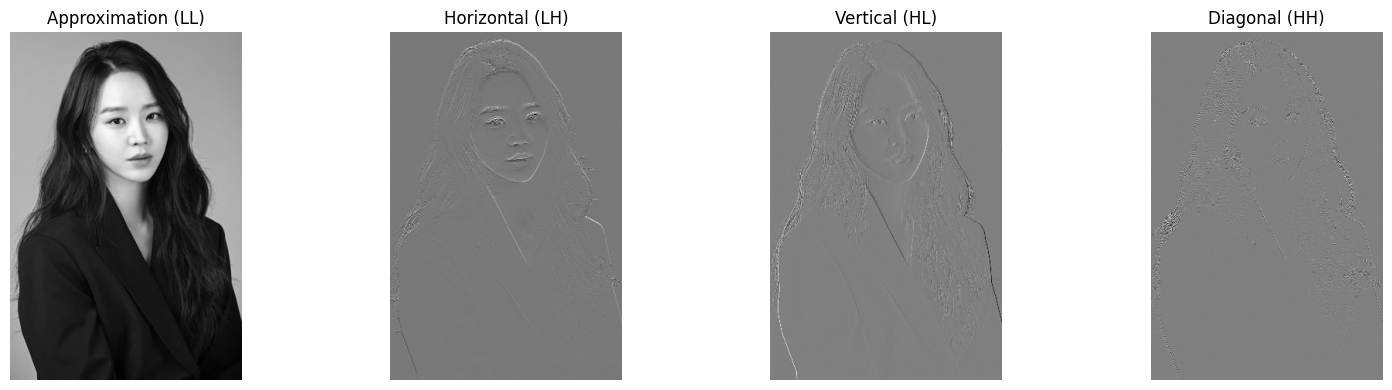

In [19]:
import cv2
import pywt
import numpy as np

# Đọc ảnh (nên dùng ảnh có nhiều chi tiết như gạch, vải)
img = cv2.imread('/home/tuong/Courses/CV/opencv-learning/sun.png', 0) 

# Thực hiện DWT mức 1 với wavelet 'haar'
# 'haar' là loại wavelet đơn giản nhất, giống như tính trung bình các pixel cạnh nhau
coeffs = pywt.dwt2(img, 'haar')
cA, (cH, cV, cD) = coeffs

# Vì giá trị sau khi biến đổi có thể rất lớn hoặc âm, 
# ta cần chuẩn hóa để hiển thị bằng OpenCV
def normalize_image(data):
    return cv2.normalize(data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
display_images(normalize_image(cA), normalize_image(cH),normalize_image(cV), normalize_image(cD), titles=['Approximation (LL)', 'Horizontal (LH)', 'Vertical (HL)', 'Diagonal (HH)']) 